# Load Libraries

In [5]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Load Data

In [6]:
features = pd.read_csv("../artifacts/data/train_features.csv")

# Plot silhouette score and davies bouldin score across k

In [7]:
k_range = range(3, 9)
silhouette_scores = []
dbi_scores = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(features)
    sil = silhouette_score(features, labels)
    dbi = davies_bouldin_score(features, labels)
    silhouette_scores.append(sil)
    dbi_scores.append(dbi)
    print(f"k={k}: silhouette={sil:.4f}, davies_bouldin={dbi:.4f}")

k=3: silhouette=0.2310, davies_bouldin=1.5872
k=4: silhouette=0.2219, davies_bouldin=1.6079
k=5: silhouette=0.2136, davies_bouldin=1.6089
k=6: silhouette=0.2027, davies_bouldin=1.5634
k=7: silhouette=0.2101, davies_bouldin=1.4560
k=8: silhouette=0.2082, davies_bouldin=1.4608


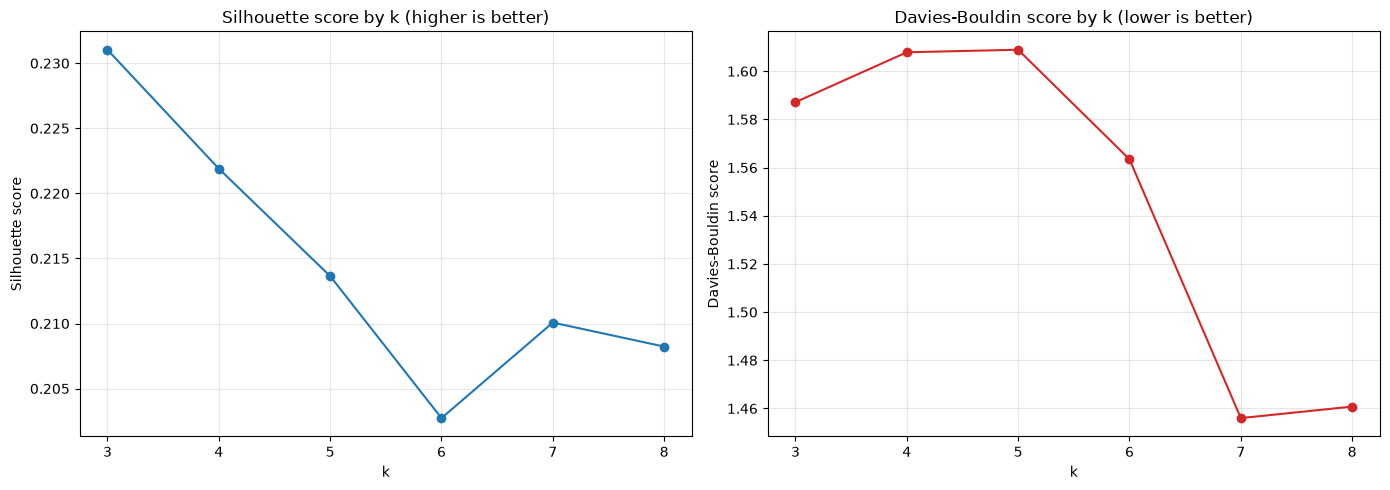


Best k by silhouette score: 3


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), silhouette_scores, marker='o', color='tab:blue')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette score')
axes[0].set_title('Silhouette score by k (higher is better)')
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), dbi_scores, marker='o', color='tab:red')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Davies-Bouldin score')
axes[1].set_title('Davies-Bouldin score by k (lower is better)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nBest k by silhouette score: {best_k}")

# 2D PCA plot

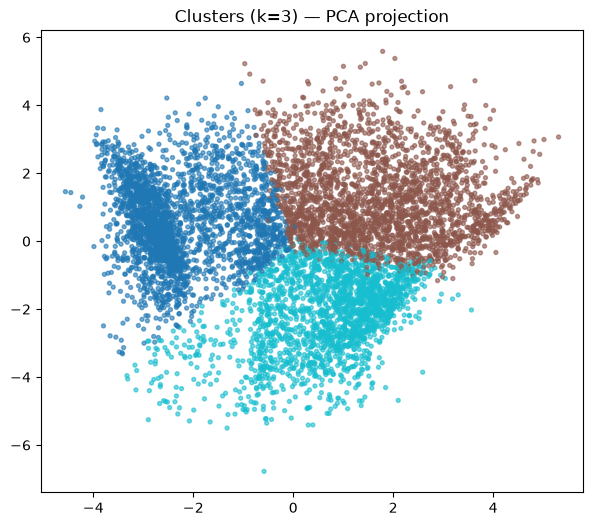

In [10]:
best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
final_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = final_model.fit_predict(features)

coords = PCA(n_components=2, random_state=42).fit_transform(features)
plt.figure(figsize=(7,6))
plt.scatter(coords[:,0], coords[:,1], c=labels, cmap='tab10', s=8, alpha=0.6)
plt.title(f'Clusters (k={best_k}) — PCA projection')
plt.show()